# SvK Data Analysis

Explore hourly consumption, generation, and losses from **data/SvK** for 2018-2026. Regions and categories remain separate columns. Temporal averages below summarize each column independently; they do not combine regions or categories.

Run from the repository root with the `.venv-win` kernel. The loader preserves source signs and MWh units. Timestamps retain the source convention; confirm timezone and daylight-saving treatment before interpreting local-hour patterns. The 2026 file covers only January-June, so annual comparisons need matching periods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from preprocess_svk import load_svk_data

plt.rcParams.update({'figure.figsize': (13, 4), 'axes.grid': True, 'grid.alpha': 0.25})
df_consumption, df_generation, df_losses = load_svk_data()
tables = {'Consumption': df_consumption, 'Generation': df_generation, 'Losses': df_losses}


d:\coding_study\repo\electricity_demand_forecasting\preprocess_svk.py:70: UserWarning: timvarden-2018-01-12.xls: unlabeled Excel column 40 contains values; excluded because its region/category is unknown (source is unchanged)
  warnings.warn(
d:\coding_study\repo\electricity_demand_forecasting\preprocess_svk.py:70: UserWarning: timvarden-2018-01-12.xls: unlabeled Excel column 41 contains values; excluded because its region/category is unknown (source is unchanged)
  warnings.warn(


timvarden-2018-01-12.xls: 8,760 timestamp rows
timvarden-2019-01-12.xls: 8,760 timestamp rows
timvarden-2020-01-12.xls: 8,784 timestamp rows
timvarden-2021-01-12.xls: 8,760 timestamp rows
timvarden-2022-01-12.xls: 8,760 timestamp rows
timvarden-2023-01-12.xls: 8,760 timestamp rows
timvarden-2024-01-12_.xls: 8,784 timestamp rows
timvarden-2025-01-12.xls: 8,760 timestamp rows
timvarden-2026-01-06.xls: 4,344 timestamp rows


## 1. Data overview and quality

Missing categories in earlier years remain `NaN`, not zero. The 2018 source contains two unlabeled populated columns that the loader reports and excludes. In 2026, onshore and offshore wind are separate categories; do not treat them as the same columns as earlier wind totals.

In [13]:
reference_index = df_consumption.index

overview = pd.DataFrame([
    {'Dataset': name, 'Rows': len(frame), 'Columns': frame.shape[1],
     'Start': frame.index.min(), 'End': frame.index.max(),
     'Granularity': frame.index.to_series().diff().dropna().mode().iloc[0],
     'Duplicate timestamps': frame.index.duplicated().sum(),
     'Missing hourly timestamps': len(
         pd.date_range(frame.index.min(), frame.index.max(), freq='h').difference(frame.index)
     ),
     'Same timestamps as Consumption': frame.index.equals(reference_index),
     'Sorted': frame.index.is_monotonic_increasing}
    for name, frame in tables.items()
]).set_index('Dataset')
display(overview)

for name, frame in tables.items():
    print(name)
    display(frame.head())
    display(pd.DataFrame({
        'Missing (%)': frame.isna().mean().mul(100),
        'Zero (%)': frame.eq(0).sum().div(frame.count().replace(0, np.nan)).mul(100),
        'First valid': frame.apply(lambda s: s.first_valid_index()),
        'Last valid': frame.apply(lambda s: s.last_valid_index()),
    }))

,Rows,Columns,Start,End,Granularity,Duplicate timestamps,Missing hourly timestamps,Same timestamps as Consumption,Sorted
Dataset,,,,,,,,,
Consumption,74472,20,2018-01-01,2026-06-30 23:00:00,0 days 01:00:00,0,0,True,True
Generation,74472,33,2018-01-01,2026-06-30 23:00:00,0 days 01:00:00,0,0,True,True
Losses,74472,8,2018-01-01,2026-06-30 23:00:00,0 days 01:00:00,0,0,True,True


Consumption


,se1_metered_consumption_excluding_interruptible_load,se2_metered_consumption_excluding_interruptible_load,se3_metered_consumption_excluding_interruptible_load,se4_metered_consumption_excluding_interruptible_load,se1_interruptible_load,se2_interruptible_load,se3_interruptible_load,se4_interruptible_load,se1_profiled_supply_consumption,se2_profiled_supply_consumption,se3_profiled_supply_consumption,se4_profiled_supply_consumption,se1_metered_consumption_over_50mw,se2_metered_consumption_over_50mw,se3_metered_consumption_over_50mw,se4_metered_consumption_over_50mw,se1_energy_storage_consumption,se2_energy_storage_consumption,se3_energy_storage_consumption,se4_energy_storage_consumption
datetime,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,-879.546411,-1324.912999,-5082.332339,-1032.212224,-15.139255,-4.28215,-35.379498,-1.820,-320.852311,-677.512910,-4146.389119,-1315.833745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 01:00:00,-854.412614,-1301.169237,-5068.952361,-1021.143207,-8.588081,-4.34295,-33.090146,-2.034,-312.872325,-655.939945,-3985.215149,-1266.761195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 02:00:00,-849.282198,-1263.349477,-5045.623694,-1002.607815,-15.368199,-4.29760,-32.917950,-2.210,-304.099395,-635.338786,-3840.439564,-1214.776332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 03:00:00,-855.437041,-1261.090204,-5018.433271,-1009.783807,-10.771903,-4.32470,-32.660058,-1.980,-296.183806,-619.271420,-3693.665116,-1162.921100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 04:00:00,-864.749933,-1257.587183,-5010.117105,-1034.710987,-15.183108,-4.49015,-32.197542,-2.072,-293.452582,-613.083015,-3609.149193,-1136.420289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing (%),Zero (%),First valid,Last valid
se1_metered_consumption_excluding_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se2_metered_consumption_excluding_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se3_metered_consumption_excluding_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se4_metered_consumption_excluding_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se1_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se2_interruptible_load,0.000000,0.028199,2018-01-01,2026-06-30 23:00:00
se3_interruptible_load,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se4_interruptible_load,0.000000,21.406703,2018-01-01,2026-06-30 23:00:00
se1_profiled_supply_consumption,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se2_profiled_supply_consumption,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00


Generation


,se1_unspecified_generation,se2_unspecified_generation,se3_unspecified_generation,se4_unspecified_generation,se1_hydro_generation,se2_hydro_generation,se3_hydro_generation,se4_hydro_generation,se1_wind_generation,se2_wind_generation,...,se3_energy_storage_generation,se4_energy_storage_generation,se1_wind_onshore,se2_wind_onshore,se3_wind_onshore,se4_wind_onshore,se1_wind_offshore,se2_wind_offshore,se3_wind_offshore,se4_wind_offshore
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.0000,0.01062,11.56062,12.782519,1567.682081,2452.401968,1371.185247,283.274302,248.367512,466.054477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 01:00:00,0.5540,0.00833,11.89710,12.719574,1168.017709,2149.582161,1253.252445,283.654948,238.104265,449.537397,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 02:00:00,0.7710,0.01621,11.62666,12.306289,985.827853,2004.395075,1216.744223,283.619570,228.781771,497.112675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 03:00:00,1.0132,0.02070,11.88815,12.639589,973.166394,1905.183572,1200.083650,283.563376,218.608491,588.583537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 04:00:00,0.7650,0.00064,11.62433,12.972690,1018.671665,1987.470981,1210.767642,283.555877,187.179221,639.385540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing (%),Zero (%),First valid,Last valid
se1_unspecified_generation,0.000000,43.226985,2018-01-01,2026-06-30 23:00:00
se2_unspecified_generation,0.000000,2.502954,2018-01-01,2026-06-30 23:00:00
se3_unspecified_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se4_unspecified_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se1_hydro_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se2_hydro_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se3_hydro_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se4_hydro_generation,0.000000,0.000000,2018-01-01,2026-06-30 23:00:00
se1_wind_generation,5.833065,0.000000,2018-01-01,2025-12-31 23:00:00
se2_wind_generation,5.833065,0.000000,2018-01-01,2025-12-31 23:00:00


Losses


,se1_profiled_supply_losses,se2_profiled_supply_losses,se3_profiled_supply_losses,se4_profiled_supply_losses,se1_metered_losses,se2_metered_losses,se3_metered_losses,se4_metered_losses
datetime,,,,,,,,
2018-01-01 00:00:00,-28.075403,-52.288821,-312.810246,-94.713027,NaN,NaN,NaN,NaN
2018-01-01 01:00:00,-27.464304,-50.574203,-299.410340,-91.175143,NaN,NaN,NaN,NaN
2018-01-01 02:00:00,-26.685033,-48.943735,-288.456633,-87.410734,NaN,NaN,NaN,NaN
2018-01-01 03:00:00,-25.991393,-47.682140,-277.178742,-83.639353,NaN,NaN,NaN,NaN
2018-01-01 04:00:00,-25.749979,-47.189229,-270.630666,-81.697897,NaN,NaN,NaN,NaN


,Missing (%),Zero (%),First valid,Last valid
se1_profiled_supply_losses,0.00000,0.0,2018-01-01,2026-06-30 23:00:00
se2_profiled_supply_losses,0.00000,0.0,2018-01-01,2026-06-30 23:00:00
se3_profiled_supply_losses,0.00000,0.0,2018-01-01,2026-06-30 23:00:00
se4_profiled_supply_losses,0.00000,0.0,2018-01-01,2026-06-30 23:00:00
se1_metered_losses,11.76281,0.0,2019-01-01,2026-06-30 23:00:00
se2_metered_losses,11.76281,0.0,2019-01-01,2026-06-30 23:00:00
se3_metered_losses,11.76281,0.0,2019-01-01,2026-06-30 23:00:00
se4_metered_losses,11.76281,0.0,2019-01-01,2026-06-30 23:00:00


## Consumption Variable Definitions

The dataset is published by **Svenska kraftnät (SVK)** and is based on measured
consumption, production, and import/export values reported by Swedish network
operators for balance settlement.

**Source:** [Svenska kraftnät – Description of the statistics](https://www.svk.se/en/stakeholders-portal/electricity-market/statistics/description-of-the-statistics/)

| English variable | Swedish term | SVK definition / description | Interpretation for this dataset |
|---|---|---|---|
| `metered_consumption_excluding_interruptible_load` | **Timmätt förbrukning exkl. avkopplingsbar last** | Hourly metered electricity consumption, with interruptible load reported separately. SVK's electricity statistics are based on measured consumption values reported by network operators for balance settlement. | This represents the main directly metered electricity consumption category, excluding loads classified as interruptible. It should therefore not automatically be interpreted as *total demand*, since other consumption categories are reported separately. |
| `interruptible_load` | **Avkopplingsbar last** | Consumption from facilities classified as interruptible/disconnectable load. Such consumption can be disconnected or curtailed under applicable contractual or system arrangements. | This is still genuine electricity consumption, but it is separated because the load has special interruptibility characteristics. It should not be interpreted as electricity that was necessarily interrupted during that hour. |
| `profiled_supply_consumption` | **Schablonleverans / schablonavräknad förbrukning** | SVK states that profile-settled consumption is allocated using the consumption profiles of profile-settled network areas and preliminary load-profile shares. The hourly allocation is linear within the month. | Consumption that is not represented in the same way as directly hourly-metered consumption. Instead, an energy quantity is allocated across hours using settlement profiles. Therefore, its hourly pattern should be interpreted more cautiously than directly metered hourly consumption. |
| `metered_consumption_over_50mw` | **Timmätt förbrukning >50 MW** | A separately reported subset/category of hourly-metered consumption associated with loads above the 50 MW threshold in the SVK statistics. | This appears to identify very large electricity-consuming facilities. It should **not** be added blindly to metered consumption without first checking whether it is a subset of the main metered-consumption category, because doing so could double-count consumption. |
| `energy_storage_consumption` | **Energilager förbrukning** | SVK distinguishes energy-storage withdrawal (**förbrukning**) from energy-storage injection (**produktion**). An energy-storage facility can both withdraw electricity from the grid and inject electricity back into the grid. | This corresponds to the charging/withdrawal side of energy storage: electricity taken from the grid by storage facilities. It is therefore consumption from the power-system perspective, although economically it is different from final household or industrial consumption. |

### Important interpretation note

These variables are **settlement/statistical categories**, not necessarily independent
components that can simply be summed together.

In particular:

- `interruptible_load` is electricity consumption, even though it is reported separately.
- `profiled_supply_consumption` is based on settlement profiles rather than the same type
  of direct hourly measurement.
- `metered_consumption_over_50mw` may represent a subset of metered consumption and
  therefore should not be added to the main metered-consumption variable without
  confirming the accounting relationship.
- `energy_storage_consumption` represents electricity withdrawn by storage facilities
  (e.g. charging), rather than conventional final consumption.

SVK also notes that its balance-settlement statistics do not capture all electricity
consumption and production. In particular, production and consumption inside certain
closed/non-concession networks can be partially missing ("hidden production"), which can
lead to an underestimation of reported consumption.

### References

1. Svenska kraftnät, **Description of the statistics**:  
   https://www.svk.se/en/stakeholders-portal/electricity-market/statistics/description-of-the-statistics/

2. Svenska kraftnät, **Beskrivning av statistiken** (Swedish version):  
   https://www.svk.se/om-kraftsystemet/kraftsystemdata/elstatistik/beskrivning-av-statistiken/

3. Svenska kraftnät, **Energy storage with batteries and hydrogen**:  
   https://www.svk.se/om-kraftsystemet/energilagring-med-batterier-och-vatgas/

In [3]:
# Timestamp gaps are checked separately from missing measurement values.
index = df_consumption.index
expected = pd.date_range(index.min(), index.max(), freq='h')
missing_hours = expected.difference(index)
print('Missing hourly timestamps:', len(missing_hours))
print('First missing timestamps:', missing_hours[:10].tolist())
display(index.to_series().diff().value_counts().rename('Count').to_frame())

# Availability by year helps reveal category changes.
for name, frame in tables.items():
    print(name, '- nonmissing observations by year')
    display(frame.notna().groupby(frame.index.year).sum())


Missing hourly timestamps: 0
First missing timestamps: []


,Count
datetime,
0 days 01:00:00,74471


Consumption - nonmissing observations by year


,se1_metered_consumption_excluding_interruptible_load,se2_metered_consumption_excluding_interruptible_load,se3_metered_consumption_excluding_interruptible_load,se4_metered_consumption_excluding_interruptible_load,se1_interruptible_load,se2_interruptible_load,se3_interruptible_load,se4_interruptible_load,se1_profiled_supply_consumption,se2_profiled_supply_consumption,se3_profiled_supply_consumption,se4_profiled_supply_consumption,se1_metered_consumption_over_50mw,se2_metered_consumption_over_50mw,se3_metered_consumption_over_50mw,se4_metered_consumption_over_50mw,se1_energy_storage_consumption,se2_energy_storage_consumption,se3_energy_storage_consumption,se4_energy_storage_consumption
datetime,,,,,,,,,,,,,,,,,,,,
2018,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,0,0,0,0,0,0,0,0
2019,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,0,0,0,0
2020,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,0,0,0,0
2021,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,0,0,0,0
2022,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,0,0,0,0
2023,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,0,0,0,0
2024,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,0,0,0,0
2025,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760
2026,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344


Generation - nonmissing observations by year


,se1_unspecified_generation,se2_unspecified_generation,se3_unspecified_generation,se4_unspecified_generation,se1_hydro_generation,se2_hydro_generation,se3_hydro_generation,se4_hydro_generation,se1_wind_generation,se2_wind_generation,...,se3_energy_storage_generation,se4_energy_storage_generation,se1_wind_onshore,se2_wind_onshore,se3_wind_onshore,se4_wind_onshore,se1_wind_offshore,se2_wind_offshore,se3_wind_offshore,se4_wind_offshore
datetime,,,,,,,,,,,,,,,,,,,,,
2018,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,0,0,0,0,0,0,0,0,0,0
2019,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,0,0,0,0,0,0,0,0,0,0
2020,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,...,0,0,0,0,0,0,0,0,0,0
2021,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,0,0,0,0,0,0,0,0,0,0
2022,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,0,0,0,0,0,0,0,0,0,0
2023,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,0,0,0,0,0,0,0,0,0,0
2024,8784,8784,8784,8784,8784,8784,8784,8784,8784,8784,...,8784,8784,0,0,0,0,0,0,0,0
2025,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760,...,8760,8760,0,0,0,0,0,0,0,0
2026,4344,4344,4344,4344,4344,4344,4344,4344,0,0,...,4344,4344,4344,4344,4344,4344,4344,4344,4344,4344


Losses - nonmissing observations by year


,se1_profiled_supply_losses,se2_profiled_supply_losses,se3_profiled_supply_losses,se4_profiled_supply_losses,se1_metered_losses,se2_metered_losses,se3_metered_losses,se4_metered_losses
datetime,,,,,,,,
2018,8760,8760,8760,8760,0,0,0,0
2019,8760,8760,8760,8760,8760,8760,8760,8760
2020,8784,8784,8784,8784,8784,8784,8784,8784
2021,8760,8760,8760,8760,8760,8760,8760,8760
2022,8760,8760,8760,8760,8760,8760,8760,8760
2023,8760,8760,8760,8760,8760,8760,8760,8760
2024,8784,8784,8784,8784,8784,8784,8784,8784
2025,8760,8760,8760,8760,8760,8760,8760,8760
2026,4344,4344,4344,4344,4344,4344,4344,4344


## 2. Select a region and time period

Change these settings and rerun the following cells. Plots show each category separately. Negative source values are preserved; no sign reversal or total-demand calculation is applied.

In [4]:
REGION = 'se3'  # se1, se2, se3, or se4
START = '2025-01-01'
END = '2025-12-31'

selected = {
    name: frame.loc[START:END, frame.columns.str.startswith(REGION + '_')]
    for name, frame in tables.items()
}
assert REGION in {'se1', 'se2', 'se3', 'se4'}
assert all(not frame.empty for frame in selected.values()), 'Select a period within the available data.'


## 3. Consumption, generation, and losses over time

Daily means reduce visual clutter while retaining each source category. These values are **mean hourly energy (MWh)**, not daily energy totals. All-missing categories in the selected period are omitted from the plots.

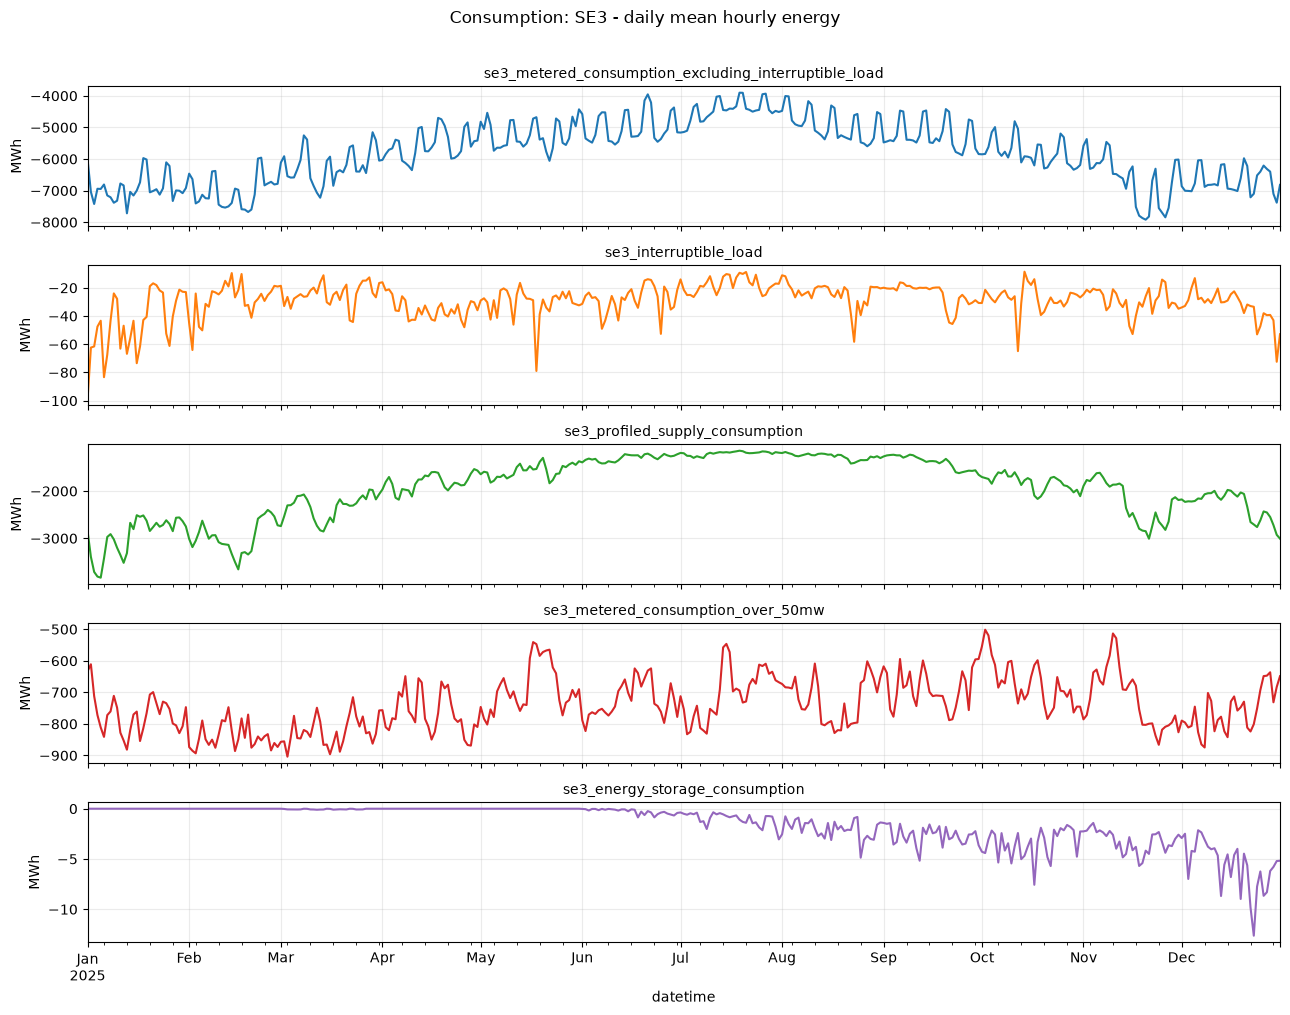

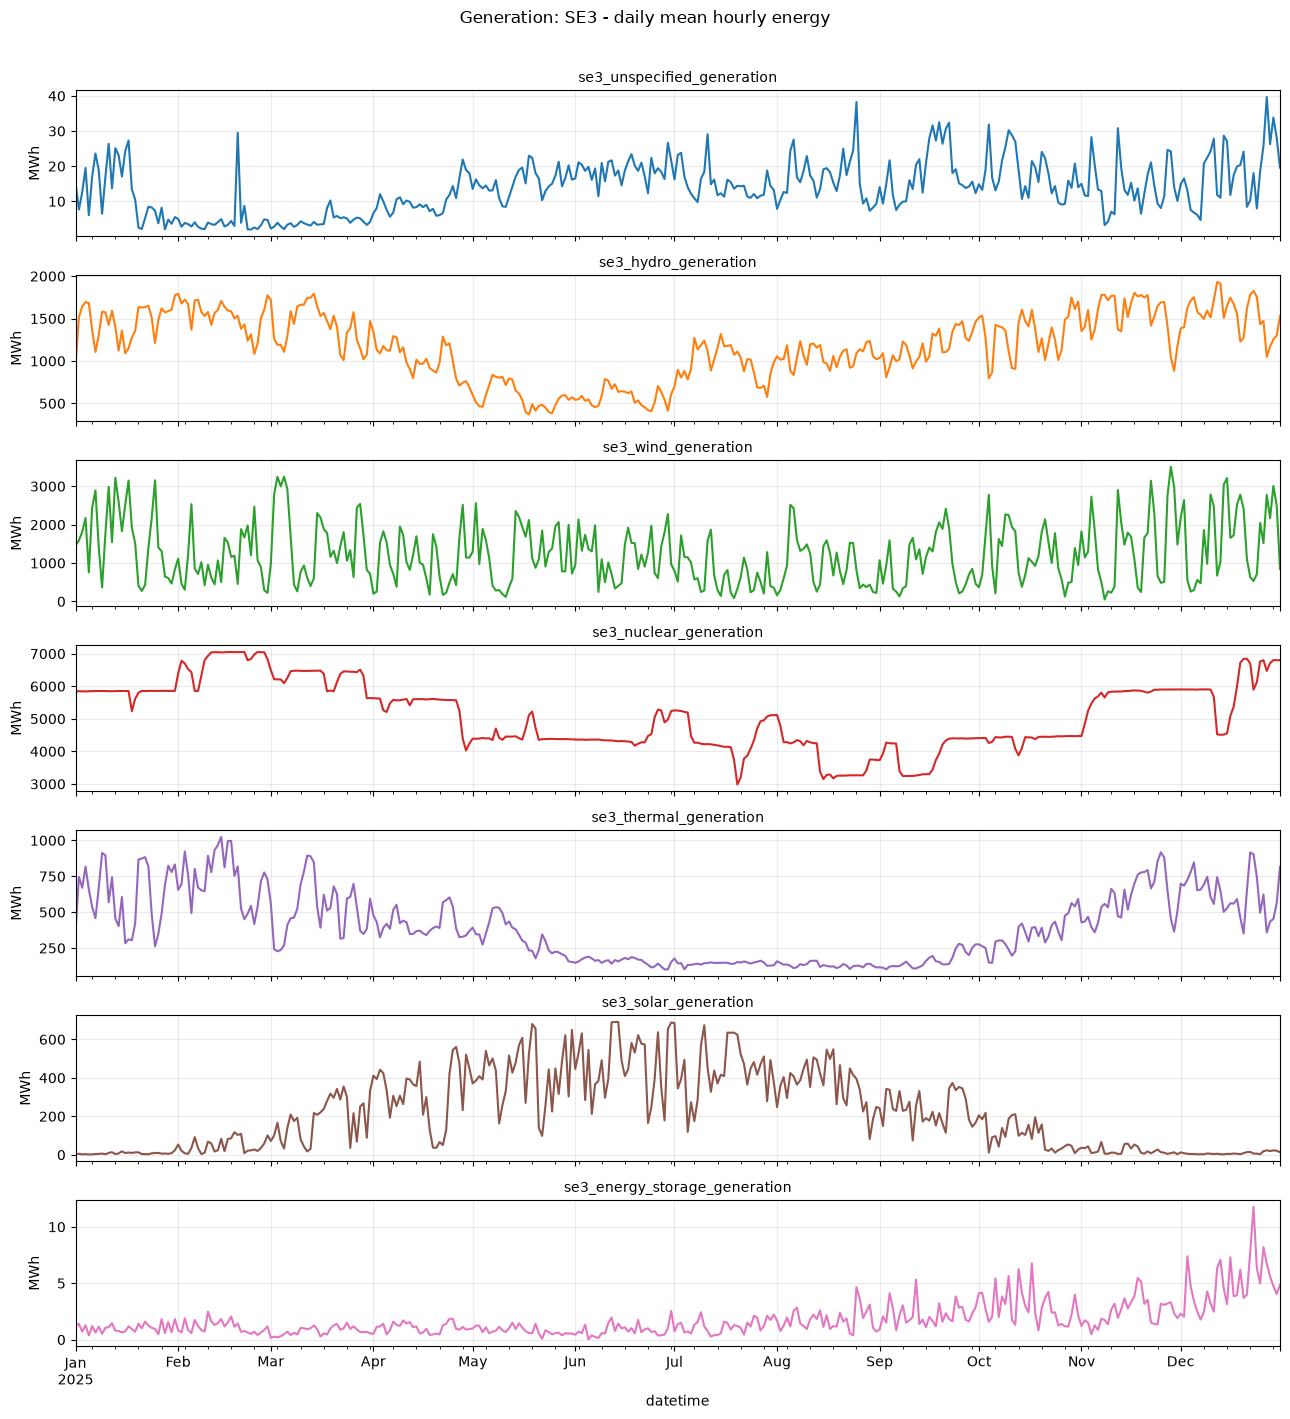

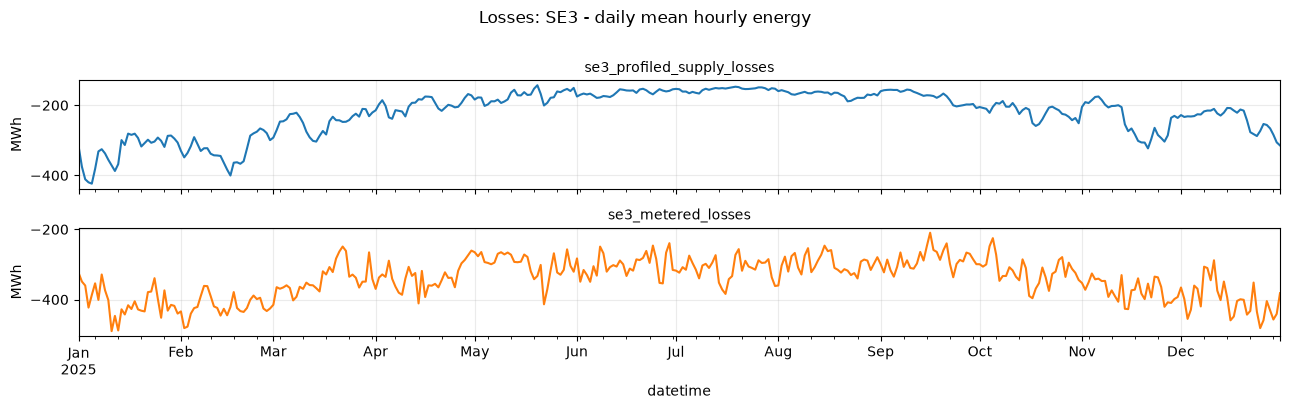

In [5]:
def plot_categories(frame, title):
    daily = frame.resample('D').mean().dropna(axis=1, how='all')
    if daily.empty:
        print('No available measurements:', title)
        return
    axes = daily.plot(subplots=True, sharex=True, legend=False,
                      figsize=(13, max(3, 2 * daily.shape[1])))
    for ax, column in zip(np.atleast_1d(axes), daily.columns):
        ax.set_title(column, fontsize=10)
        ax.set_ylabel('MWh')
    np.atleast_1d(axes)[0].figure.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

for name, frame in selected.items():
    plot_categories(frame, f'{name}: {REGION.upper()} - daily mean hourly energy')


## 4. Compare regions within the same category

Choose one category below. Region series are plotted independently, without summing them. The default metered-consumption category excludes interruptible load and is not a complete national-demand target.

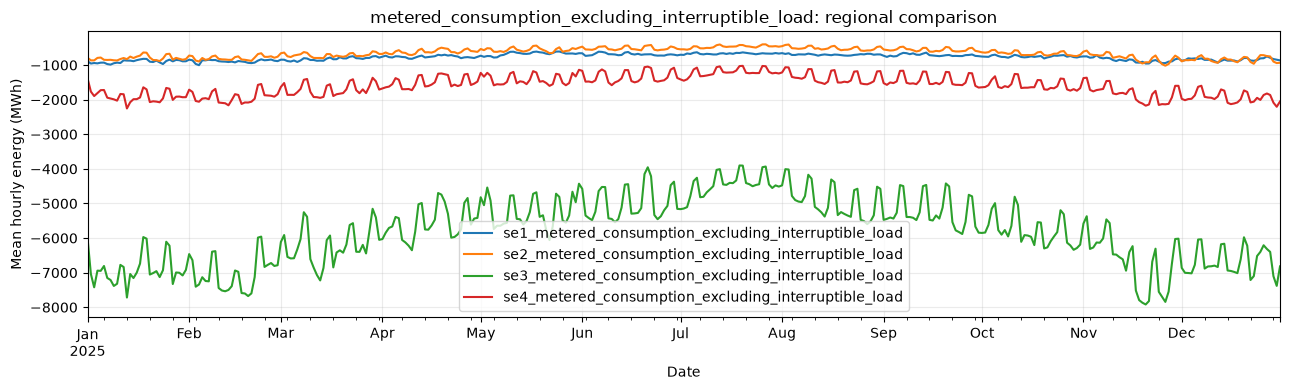

In [6]:
DATASET = 'Consumption'
CATEGORY = 'metered_consumption_excluding_interruptible_load'
frame = tables[DATASET]
columns = [f'{region}_{CATEGORY}' for region in ['se1', 'se2', 'se3', 'se4']
           if f'{region}_{CATEGORY}' in frame.columns]
assert columns, 'Choose a category present in the selected dataset.'
ax = frame.loc[START:END, columns].resample('D').mean().plot()
ax.set(title=f'{CATEGORY}: regional comparison', xlabel='Date', ylabel='Mean hourly energy (MWh)')
plt.tight_layout()
plt.show()


## 5. Hourly, weekly, and monthly patterns

Profiles use only the selected period. Each point is a mean of observed values, so check missingness before comparing profiles. Calendar hours follow the unconverted source timestamps.

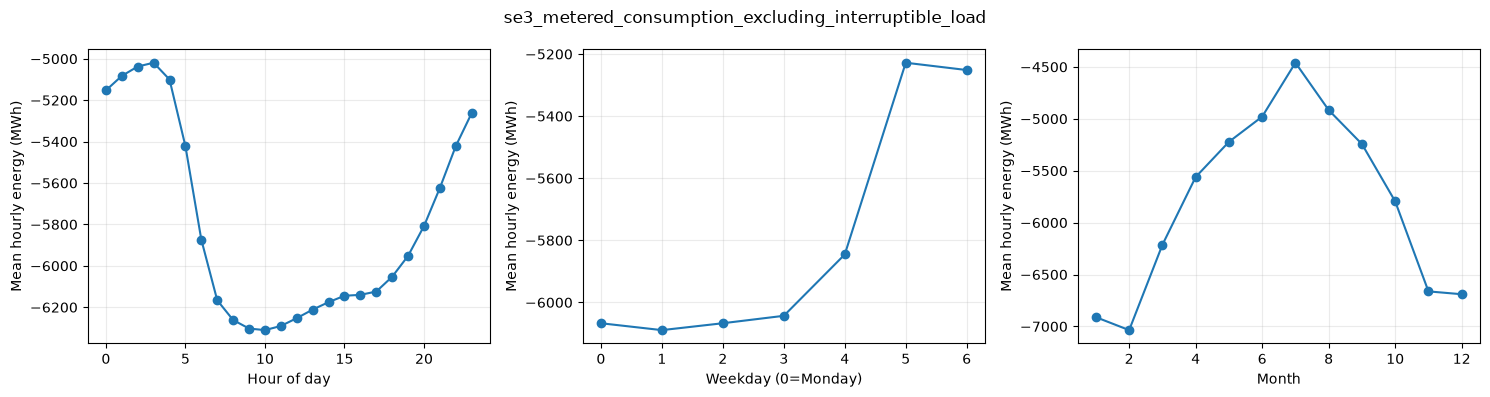

In [7]:
SERIES = f'{REGION}_metered_consumption_excluding_interruptible_load'
series = df_consumption.loc[START:END, SERIES]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in [
    (axes[0], series.index.hour, 'Hour of day'),
    (axes[1], series.index.dayofweek, 'Weekday (0=Monday)'),
    (axes[2], series.index.month, 'Month'),
]:
    series.groupby(labels).mean().plot(ax=ax, marker='o')
    ax.set(xlabel=title, ylabel='Mean hourly energy (MWh)')
fig.suptitle(SERIES)
plt.tight_layout()
plt.show()


## 6. Historical relationships and forecasting questions

Lag correlations describe persistence; they are not forecast accuracy measurements. Lag positions correspond to hours only when the index is regular and unique. Generation correlations would also be descriptive: actual target-hour generation is unavailable at a day-ahead forecast issue time.

In [8]:
if series.index.is_unique and (series.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all():
    display(pd.DataFrame({
        'Lag (hours)': [1, 24, 48, 168, 336, 720],
        'Correlation': [series.corr(series.shift(lag)) for lag in [1, 24, 48, 168, 336, 720]],
    }).set_index('Lag (hours)'))
else:
    print('Resolve timestamp gaps or duplicates before interpreting row-based lags as hours.')


,Correlation
Lag (hours),
1,0.984598
24,0.882156
48,0.758286
168,0.918642
336,0.884784
720,0.582541


In [15]:
df_demand = df_consumption.filter(regex=r'^se3_').copy()
df_generation = df_generation.filter(regex=r'^se3_').copy()
df_loss = df_losses.filter(regex=r'^se3_').copy()

display(df_demand.head())
display(df_generation.head())
display(df_loss.head())

,se3_metered_consumption_excluding_interruptible_load,se3_interruptible_load,se3_profiled_supply_consumption,se3_metered_consumption_over_50mw,se3_energy_storage_consumption
datetime,,,,,
2018-01-01 00:00:00,-5082.332339,-35.379498,-4146.389119,NaN,NaN
2018-01-01 01:00:00,-5068.952361,-33.090146,-3985.215149,NaN,NaN
2018-01-01 02:00:00,-5045.623694,-32.917950,-3840.439564,NaN,NaN
2018-01-01 03:00:00,-5018.433271,-32.660058,-3693.665116,NaN,NaN
2018-01-01 04:00:00,-5010.117105,-32.197542,-3609.149193,NaN,NaN


,se3_unspecified_generation,se3_hydro_generation,se3_wind_generation,se3_nuclear_generation,se3_thermal_generation,se3_solar_generation,se3_energy_storage_generation,se3_wind_onshore,se3_wind_offshore
datetime,,,,,,,,,
2018-01-01 00:00:00,11.56062,1371.185247,764.836097,8534.18,736.806628,0.019905,NaN,NaN,NaN
2018-01-01 01:00:00,11.89710,1253.252445,656.174814,8534.12,730.904861,0.020797,NaN,NaN,NaN
2018-01-01 02:00:00,11.62666,1216.744223,588.884484,8533.39,716.698685,0.024614,NaN,NaN,NaN
2018-01-01 03:00:00,11.88815,1200.083650,536.230328,8533.44,667.963665,0.023649,NaN,NaN,NaN
2018-01-01 04:00:00,11.62433,1210.767642,477.091549,8533.48,664.533327,0.020190,NaN,NaN,NaN


,se3_profiled_supply_losses,se3_metered_losses
datetime,,
2018-01-01 00:00:00,-312.810246,NaN
2018-01-01 01:00:00,-299.410340,NaN
2018-01-01 02:00:00,-288.456633,NaN
2018-01-01 03:00:00,-277.178742,NaN
2018-01-01 04:00:00,-270.630666,NaN


In [16]:
from pathlib import Path

output_dir = Path("data/clean/SvK/SE3")
output_dir.mkdir(parents=True, exist_ok=True)

df_demand.to_csv(
    output_dir / "consumption_2018_2026_SE3.csv",
    index=True,
    index_label="datetime",
)

df_generation.to_csv(
    output_dir / "generation_2018_2026_SE3.csv",
    index=True,
    index_label="datetime",
)

df_loss.to_csv(
    output_dir / "losses_2018_2026_SE3.csv",
    index=True,
    index_label="datetime",
)

print(f"Saved SE3 datasets to: {output_dir.resolve()}")

Saved SE3 datasets to: D:\coding_study\repo\electricity_demand_forecasting\data\clean\SvK\SE3


## 7. Findings and next steps

Record observations after inspecting the charts:

- Which regions and categories have stable coverage, and which change over time?
- When do consumption, generation, and losses peak within the selected period?
- Which missing values reflect unavailable categories rather than missing measurements?
- What consumption category or explicitly defined combination should become the forecast target? Check definitions and overlaps before summing anything.
- Confirm source signs, timezone, and measurement publication delays.
- Define the day-ahead forecast issue time, then build only features available at that time.
- Compare seasonal-naive baselines and models using chronological validation; reserve a later test period for final evaluation.

Avoid comparing full-year totals with partial 2026 coverage without restricting both to matching dates.